# **Задание 3**

## **1) Импорты**

In [1]:
from collections import Counter, defaultdict
from pathlib import Path
import random
import shutil

import cv2
import numpy as np
import pandas as pd
import yaml

import torch

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from ultralytics import YOLO

/home/k6zma/Documents/ML/HW3/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **2) Настройка окружения**

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)
device

device(type='cuda')

In [4]:
DATA_ROOT = Path("clothes")
SOURCE_IMAGES = DATA_ROOT / "train" / "images"
SOURCE_LABELS = DATA_ROOT / "train" / "labels"

WORK_DIR = Path("artifacts/hw3")
YOLO_DATA_ROOT = WORK_DIR / "clothes_yolo_seg"
YOLO_DATA_YAML = YOLO_DATA_ROOT / "data.yaml"

IMG_SIZE = 540
BATCH_SIZE = 32
EPOCHS = 50
PATIENCE = 10

MODEL_NAME = "yolo26x-seg.pt"
FALLBACK_MODEL_NAME = "yolo26x-seg.yaml"
PROJECT_NAME = str(WORK_DIR / "runs")
RUN_NAME = "yolo26x_seg_clothes_fast"

## **3) Анализ датасета**

In [9]:
with open(DATA_ROOT / "data.yaml", "r") as f:
    source_yaml = yaml.safe_load(f)

class_names = source_yaml["names"]
num_classes = source_yaml["nc"]

class_names

['long_sleeved_dress',
 'long_sleeved_outwear',
 'long_sleeved_shirt',
 'short_sleeved_dress',
 'short_sleeved_shirt',
 'shorts',
 'skirt',
 'sling_dress',
 'trousers',
 'vest',
 'vest_dress']

In [10]:
def read_yolo_seg_labels(label_path: Path):
    objects = []
    if not label_path.exists():
        return objects

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 7:
                continue

            cls_id = int(float(parts[0]))
            points = np.array([float(x) for x in parts[1:]], dtype=np.float32).reshape(-1, 2)
            objects.append({"class_id": cls_id, "points": points})

    return objects


def collect_dataset_info(images_dir: Path, labels_dir: Path) -> pd.DataFrame:
    records = []
    image_paths = sorted(list(images_dir.glob("*.jpg")) + list(images_dir.glob("*.jpeg")) + list(images_dir.glob("*.png")))

    for image_path in image_paths:
        label_path = labels_dir / f"{image_path.stem}.txt"
        objects = read_yolo_seg_labels(label_path)
        class_ids = [obj["class_id"] for obj in objects]

        if len(class_ids) == 0:
            continue

        records.append(
            {
                "image_path": image_path,
                "label_path": label_path,
                "objects_count": len(objects),
                "class_ids": class_ids,
                "main_class": class_ids[0],
            }
        )

    return pd.DataFrame(records)


df = collect_dataset_info(SOURCE_IMAGES, SOURCE_LABELS)
df.head()

,image_path,label_path,objects_count,class_ids,main_class
0,clothes/train/images/000025_jpg.rf.bb47eac6e1b...,clothes/train/labels/000025_jpg.rf.bb47eac6e1b...,2,"[4, 6]",4
1,clothes/train/images/000028_jpg.rf.1aaa74bb964...,clothes/train/labels/000028_jpg.rf.1aaa74bb964...,2,"[4, 6]",4
2,clothes/train/images/000031_jpg.rf.174049e9d0f...,clothes/train/labels/000031_jpg.rf.174049e9d0f...,2,"[6, 4]",6
3,clothes/train/images/000032_jpg.rf.8a02ba54aae...,clothes/train/labels/000032_jpg.rf.8a02ba54aae...,2,"[6, 4]",6
4,clothes/train/images/000033_jpg.rf.7176e974948...,clothes/train/labels/000033_jpg.rf.7176e974948...,1,[5],5


In [11]:
class_counter = Counter()
for class_ids in df["class_ids"]:
    class_counter.update(class_ids)

class_counts = pd.DataFrame(
    {
        "class_id": list(range(num_classes)),
        "class_name": class_names,
        "objects_count": [class_counter[i] for i in range(num_classes)],
    }
)

len(df)

9441

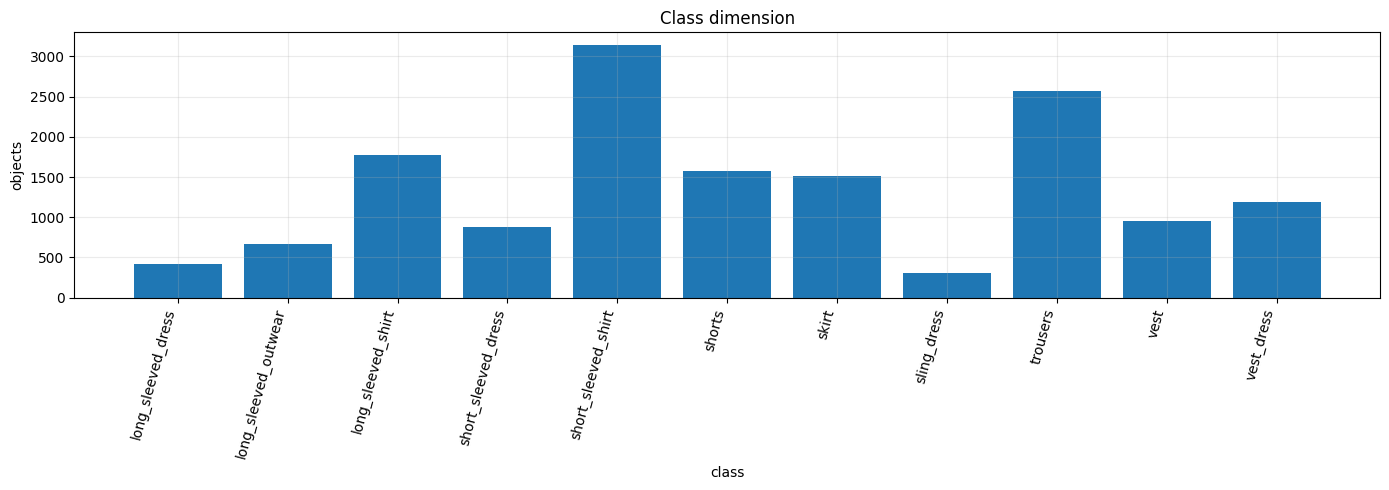

In [12]:
plt.figure(figsize=(14, 5))
plt.bar(class_counts["class_name"], class_counts["objects_count"])
plt.title("Class dimension")
plt.xlabel("class")
plt.ylabel("objects")
plt.xticks(rotation=75, ha="right")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## **4) Визуализация разметки**

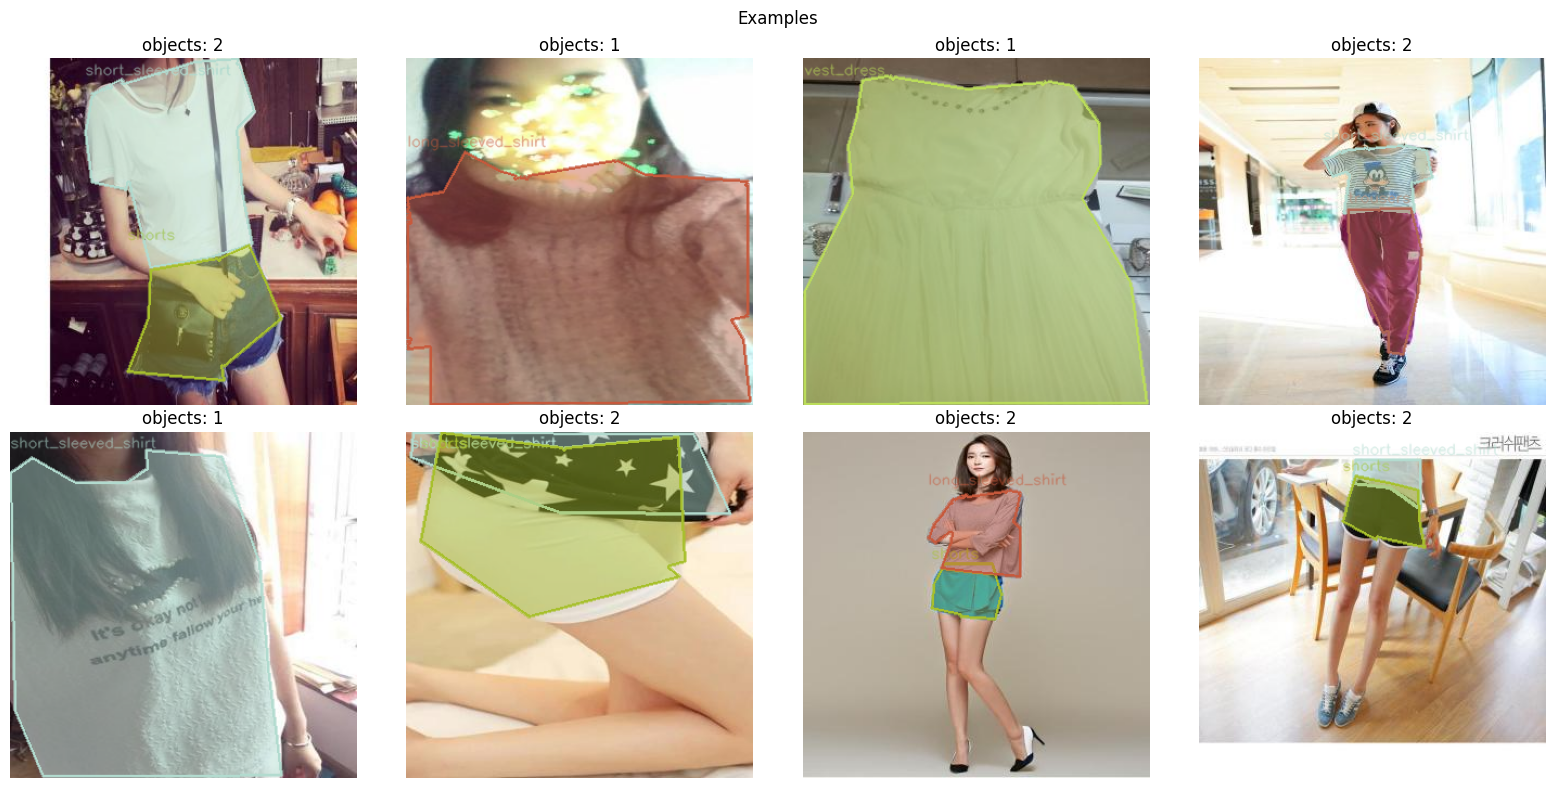

In [13]:
def draw_segmentation_sample(image_path: Path, label_path: Path, class_names: list[str], alpha: float = 0.45):
    image_bgr = cv2.imread(str(image_path))
    image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]

    overlay = image.copy()
    objects = read_yolo_seg_labels(label_path)

    for obj in objects:
        cls_id = obj["class_id"]
        points = obj["points"].copy()
        points[:, 0] *= w
        points[:, 1] *= h
        polygon = points.astype(np.int32)

        color = tuple(int(c) for c in np.random.default_rng(cls_id).integers(40, 230, size=3))
        cv2.fillPoly(overlay, [polygon], color=color)
        cv2.polylines(image, [polygon], isClosed=True, color=color, thickness=2)

        x, y = polygon.min(axis=0)
        cv2.putText(
            image,
            class_names[cls_id],
            (int(x), int(max(y - 5, 15))),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            color,
            1,
            cv2.LINE_AA,
        )

    image = cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0)

    return image


sample_df = df[df["objects_count"] > 0].sample(8, random_state=SEED).reset_index(drop=True)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, row in zip(axes, sample_df.itertuples()):
    image = draw_segmentation_sample(row.image_path, row.label_path, class_names)
    ax.imshow(image)
    ax.set_title(f"objects: {row.objects_count}")
    ax.axis("off")

plt.suptitle("Examples")
plt.tight_layout()
plt.show()

## **5) Подготовка train / val / test**

In [14]:
def split_data(frame: pd.DataFrame, train_frac=0.8, val_frac=0.1, seed=42):
    rng = random.Random(seed)
    train_parts = []
    val_parts = []
    test_parts = []

    for _, group in frame.groupby("main_class"):
        indices = group.index.tolist()
        rng.shuffle(indices)

        n_total = len(indices)
        n_train = int(n_total * train_frac)
        n_val = int(n_total * val_frac)

        train_parts.extend(indices[:n_train])
        val_parts.extend(indices[n_train:n_train + n_val])
        test_parts.extend(indices[n_train + n_val:])

    train_df = frame.loc[train_parts].sample(frac=1.0, random_state=seed).reset_index(drop=True)
    val_df = frame.loc[val_parts].sample(frac=1.0, random_state=seed).reset_index(drop=True)
    test_df = frame.loc[test_parts].sample(frac=1.0, random_state=seed).reset_index(drop=True)

    return train_df, val_df, test_df


train_df, val_df, test_df = split_data(df, train_frac=0.8, val_frac=0.1, seed=SEED)

print(f"Train: {len(train_df)}")
print(f"Validation: {len(val_df)}")
print(f"Test: {len(test_df)}")

Train: 7550
Validation: 938
Test: 953


In [15]:
def link_or_copy(src: Path, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists() or dst.is_symlink():
        return

    try:
        dst.symlink_to(src.resolve())
    except OSError:
        shutil.copy2(src, dst)


def prepare_yolo_dataset(split_frames: dict[str, pd.DataFrame], output_root: Path, class_names: list[str], rebuild=True):
    if rebuild and output_root.exists():
        shutil.rmtree(output_root)

    for split_name, split_frame in split_frames.items():
        images_dir = output_root / split_name / "images"
        labels_dir = output_root / split_name / "labels"
        images_dir.mkdir(parents=True, exist_ok=True)
        labels_dir.mkdir(parents=True, exist_ok=True)

        for row in tqdm(split_frame.itertuples(), total=len(split_frame), desc=split_name):
            image_src = Path(row.image_path)
            label_src = Path(row.label_path)

            link_or_copy(image_src, images_dir / image_src.name)
            link_or_copy(label_src, labels_dir / label_src.name)

    data_config = {
        "path": str(output_root.resolve()),
        "train": "train/images",
        "val": "val/images",
        "test": "test/images",
        "nc": len(class_names),
        "names": class_names,
    }

    with open(output_root / "data.yaml", "w") as f:
        yaml.safe_dump(data_config, f, allow_unicode=True, sort_keys=False)

    return output_root / "data.yaml"


YOLO_DATA_YAML = prepare_yolo_dataset(
    {"train": train_df, "val": val_df, "test": test_df},
    YOLO_DATA_ROOT,
    class_names,
    rebuild=True,
)

YOLO_DATA_YAML

test: 100%|██████████| 953/953 [00:00<00:00, 5034.63it/s]


PosixPath('artifacts/hw3/clothes_yolo_seg/data.yaml')

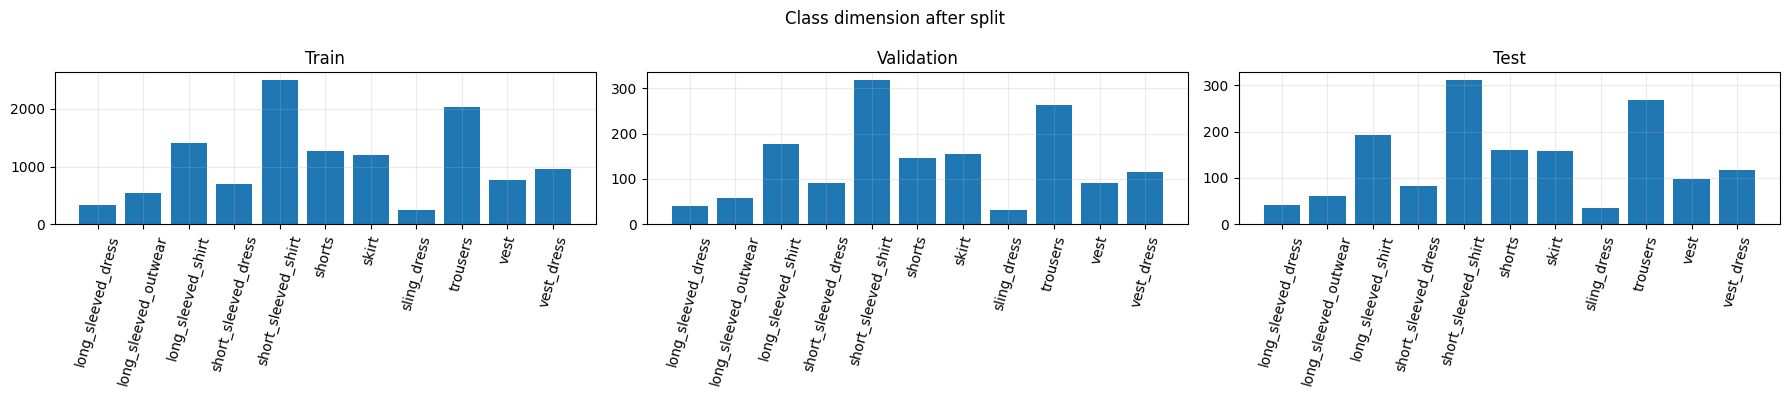

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, frame, title in zip(axes, [train_df, val_df, test_df], ["Train", "Validation", "Test"]):
    counter = Counter()
    for class_ids in frame["class_ids"]:
        counter.update(class_ids)

    values = [counter[i] for i in range(num_classes)]
    ax.bar(class_names, values)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=75)
    ax.grid(alpha=0.25)

plt.suptitle("Class dimension after split")
plt.tight_layout()
plt.show()

## **6) Модель YOLO26-seg**

In [17]:
def build_yolo26_model(model_name: str = MODEL_NAME, fallback_model_name: str = FALLBACK_MODEL_NAME):
    try:
        model = YOLO(model_name)
        print(f"Loaded model: {model_name}")
    except Exception as exc:
        print(f"Failed load model {model_name}: {exc}")
        model = YOLO(fallback_model_name)

    return model


model = build_yolo26_model()

Loaded model: yolo26x-seg.pt


## **7) Обучение**

In [6]:
yolo_device = 0 if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
yolo_device

0

In [14]:
train_results = model.train(
    data=str(YOLO_DATA_YAML),
    task="segment",
    imgsz=IMG_SIZE,
    epochs=EPOCHS,
    batch=BATCH_SIZE,
    patience=PATIENCE,
    device=yolo_device,
    workers=0,
    seed=SEED,
    project=PROJECT_NAME,
    name=RUN_NAME,
    exist_ok=True,
    pretrained=True,
    cache=True,
    multi_scale=False,
    close_mosaic=5,
    plots=True,
)

New https://pypi.org/project/ultralytics/8.4.41 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.33 🚀 Python-3.12.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15828MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=5, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=artifacts/hw3/clothes_yolo_seg/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=540, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26x-seg.pt, momentum=0.937, mosaic=1.0, multi_sca

## **8) Метрики и графики обучения**

In [18]:
history = pd.read_csv("runs/segment/artifacts/hw3/runs/yolo26n_seg_clothes_fast/results.csv")
history.columns = [col.strip() for col in history.columns]
history.tail()

,epoch,time,train/box_loss,train/seg_loss,train/cls_loss,train/dfl_loss,train/sem_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),...,metrics/mAP50(M),metrics/mAP50-95(M),val/box_loss,val/seg_loss,val/cls_loss,val/dfl_loss,val/sem_loss,lr/pg0,lr/pg1,lr/pg2
45,46,3663.70,0.62563,1.24055,0.44214,0.01330,0.23960,0.85499,0.82727,0.90054,...,0.88268,0.69111,0.64153,1.39056,0.56640,0.01368,0,0.000073,0.000073,0.000073
46,47,3734.45,0.62022,1.21710,0.42220,0.01309,0.22840,0.87141,0.81725,0.90868,...,0.89215,0.69666,0.63647,1.39953,0.55275,0.01353,0,0.000059,0.000059,0.000059
47,48,3805.25,0.60751,1.20072,0.40978,0.01273,0.21515,0.89282,0.79106,0.90336,...,0.88530,0.69264,0.63452,1.38967,0.54970,0.01347,0,0.000046,0.000046,0.000046
48,49,3876.16,0.59677,1.18812,0.39526,0.01254,0.21149,0.89325,0.81318,0.90750,...,0.88951,0.69812,0.62440,1.38244,0.54673,0.01315,0,0.000033,0.000033,0.000033
49,50,3946.92,0.59687,1.19028,0.39721,0.01244,0.21061,0.88761,0.81276,0.90903,...,0.89345,0.70044,0.62661,1.38187,0.53944,0.01321,0,0.000020,0.000020,0.000020


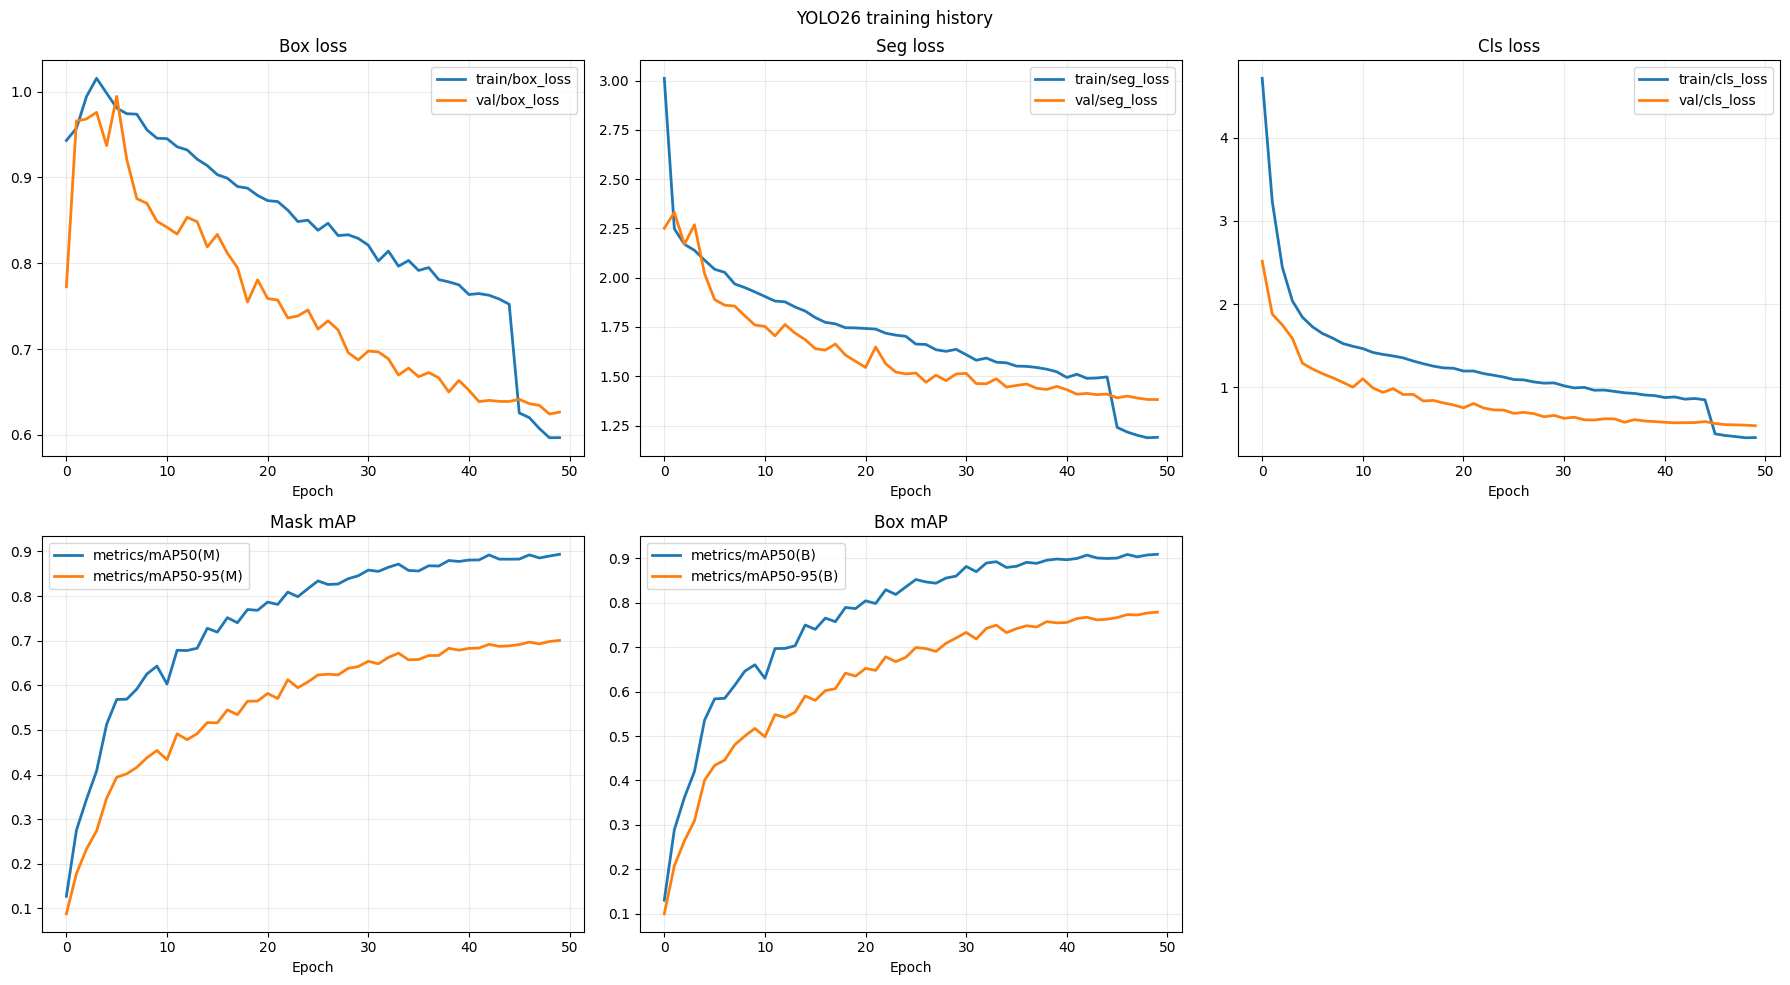

In [19]:
def plot_yolo_history(history: pd.DataFrame):
    metrics = [
        (["train/box_loss", "val/box_loss"], "Box loss"),
        (["train/seg_loss", "val/seg_loss"], "Seg loss"),
        (["train/cls_loss", "val/cls_loss"], "Cls loss"),
        (["metrics/mAP50(M)", "metrics/mAP50-95(M)"], "Mask mAP"),
        (["metrics/mAP50(B)", "metrics/mAP50-95(B)"], "Box mAP"),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for i, (cols, title) in enumerate(metrics):
        ax = axes[i]
        for col in cols:
            if col in history.columns:
                ax.plot(history[col], label=col, linewidth=2)

        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.grid(alpha=0.25)
        ax.legend()

    axes[-1].axis("off")
    plt.suptitle("YOLO26 training history")
    plt.tight_layout()
    plt.show()


plot_yolo_history(history)

In [17]:
best_model_path = "runs/segment/artifacts/hw3/runs/yolo26n_seg_clothes_fast/weights/best.pt"
best_model = YOLO(str(best_model_path))

val_metrics = best_model.val(
    data=str(YOLO_DATA_YAML),
    split="val",
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=yolo_device,
    plots=True,
)

val_metrics

WARNING ⚠️ imgsz=[540] must be multiple of max stride 32, updating to [544]
Ultralytics 8.4.33 🚀 Python-3.12.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15828MiB)
YOLO26n-seg summary (fused): 139 layers, 2,691,029 parameters, 0 gradients, 9.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1037.1±307.4 MB/s, size: 16.4 KB)
val: Scanning /home/k6zma/Documents/ML/HW3/artifacts/hw3/clothes_yolo_seg/val/labels.cache... 938 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 938/938 655.7Mit/s 0.0s


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 30/30 4.1it/s 7.3s0.1s
                   all        938       1488      0.891      0.806       0.91      0.769      0.885      0.792      0.894      0.692
    long_sleeved_dress         40         41      0.891      0.829      0.898      0.816      0.892      0.805      0.898      0.763
  long_sleeved_outwear         59         59      0.905      0.695       0.86       0.73      0.825      0.627       0.74      0.469
    long_sleeved_shirt        173        176      0.869      0.807      0.895      0.775      0.882       0.81        0.9      0.709
   short_sleeved_dress         90         90      0.856      0.833      0.908      0.808      0.852      0.822      0.893      0.713
   short_sleeved_shirt        316        319      0.888      0.867      0.937      0.807      0.884      0.861      0.937      0.733
                shorts     

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b959c3a9130>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038

In [18]:
test_metrics = best_model.val(
    data=str(YOLO_DATA_YAML),
    split="test",
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=yolo_device,
    plots=True,
)

test_metrics

WARNING ⚠️ imgsz=[540] must be multiple of max stride 32, updating to [544]
Ultralytics 8.4.33 🚀 Python-3.12.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15828MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 107.6±37.2 MB/s, size: 14.9 KB)
val: Scanning /home/k6zma/Documents/ML/HW3/artifacts/hw3/clothes_yolo_seg/test/labels... 953 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 953/953 2.9Kit/s 0.3s0.0ss
val: New cache created: /home/k6zma/Documents/ML/HW3/artifacts/hw3/clothes_yolo_seg/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 30/30 6.5it/s 4.6s0.1s
                   all        953       1529       0.88      0.822      0.896      0.762       0.88      0.805      0.881      0.682
    long_sleeved_dress         42         42      0.884      0.714      0.823      0.744      0.906      0.689      0.823      0.679
  long_sleeved_outwear     

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b9529236e70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038

## **9) Инференс на тестовых изображениях**

WARNING ⚠️ imgsz=[540] must be multiple of max stride 32, updating to [544]


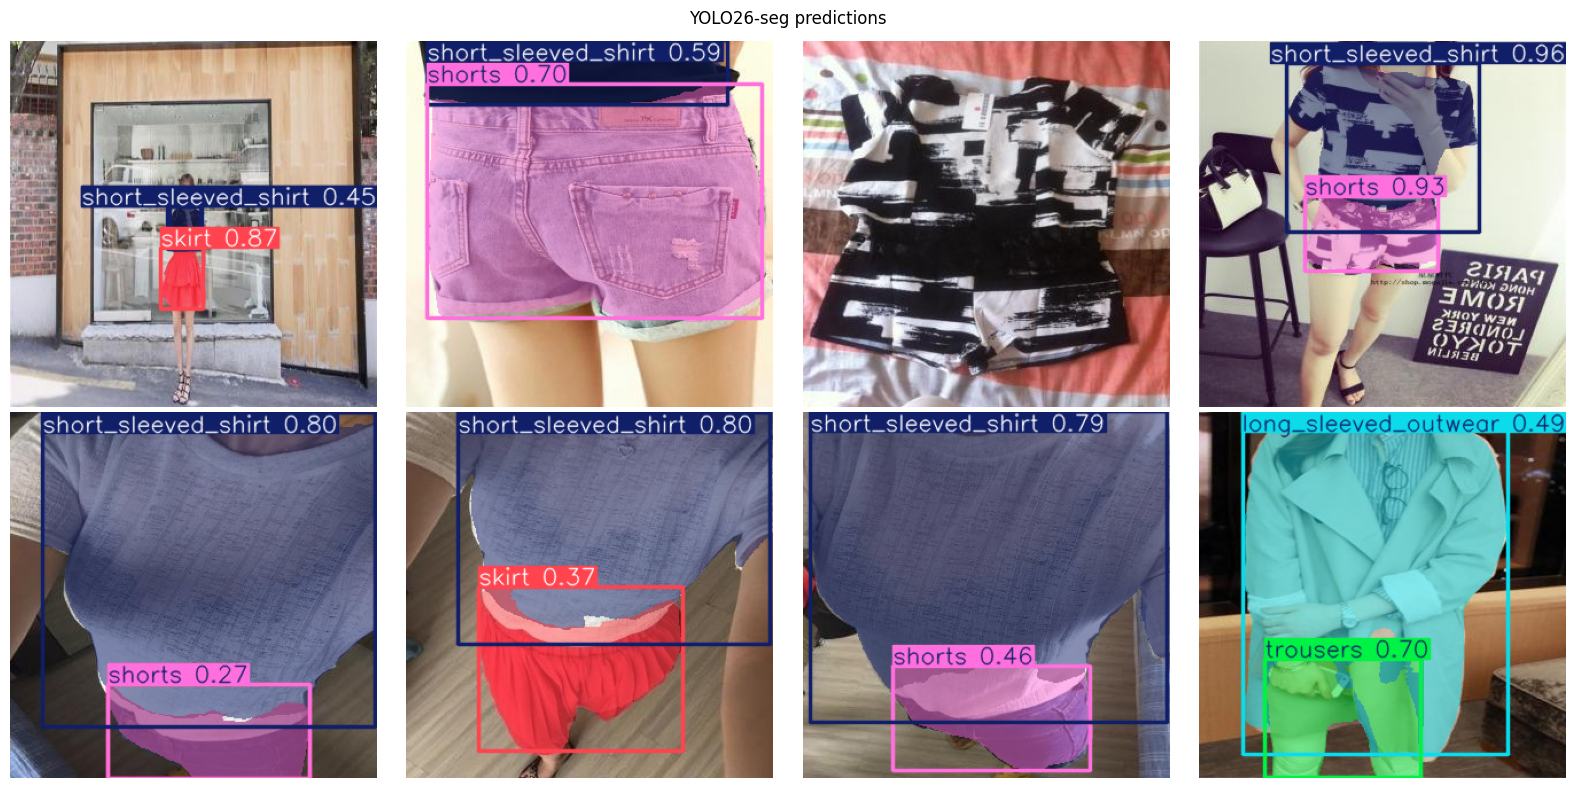

In [ ]:
test_images = sorted((YOLO_DATA_ROOT / "test" / "images").glob("*.jpg"))[:8]

pred_results = best_model.predict(
    source=[str(path) for path in test_images],
    imgsz=IMG_SIZE,
    conf=0.25,
    device=yolo_device,
    save=False,
    verbose=False,
)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, result in zip(axes, pred_results):
    image = result.plot()
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    ax.imshow(image)
    ax.axis("off")

plt.suptitle("YOLO26 predictions")
plt.tight_layout()
plt.show()

WARNING ⚠️ imgsz=[540] must be multiple of max stride 32, updating to [544]


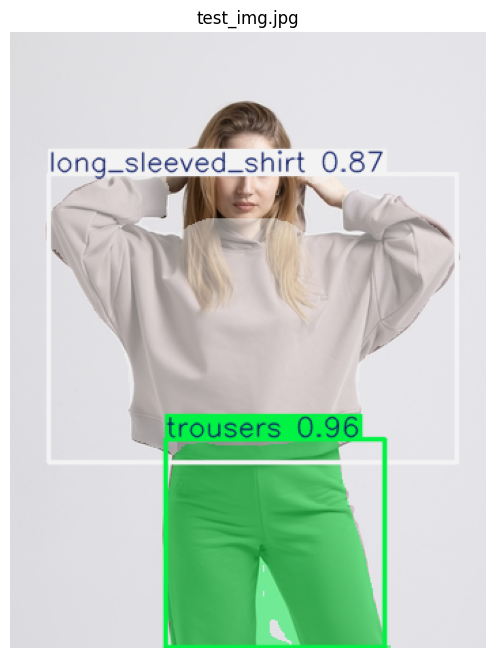

In [8]:
CUSTOM_IMAGE_PATH = "test_img.jpg"

custom_image_path = Path(CUSTOM_IMAGE_PATH)

best_model_path = "runs/segment/artifacts/hw3/runs/yolo26n_seg_clothes_fast/weights/best.pt"

custom_model = YOLO(str(best_model_path))
custom_result = custom_model.predict(
    source=str(custom_image_path),
    imgsz=IMG_SIZE,
    conf=0.25,
    device=yolo_device,
    save=False,
    verbose=False,
)[0]

image = custom_result.plot()
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.title(custom_image_path.name)
plt.axis("off")
plt.show()